# 02 — Power and experiment design

Sample-size planning. Two methods, both should agree:

1. **Analytical** via `statsmodels.stats.power.NormalIndPower`. Solves for sample size given an effect size (Cohen's h).
2. **Simulation** via Monte Carlo. Generate `n_sims` two-proportion experiments at a given sample size with the true lift baked in, count the share that reject the null. This is empirical power.

If the two disagree by more than ~2 percentage points, somebody has a bug. Cross-checking analytical formulas against simulation is the senior-analyst move that catches MDE confusion (relative vs absolute), wrong tail of the test, and effect-size definition mistakes.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd

from src import config
from src.power import analytical_sample_size, simulate_power, power_curve, mde_curve
from src.viz import power_curve_plot

FIG_DIR = ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Inputs

Baseline conversion comes from the analytical funnel completion rate. MDE follows the spec hypothesis ("at least 2pp"). Alpha and power are conventional defaults.

In [2]:
BASELINE = config.baseline_completion_rate()
MDE_PP = 2.0
ALPHA = 0.05
POWER = 0.80

print(f'baseline rate (control): {BASELINE:.4f}')
print(f'MDE (absolute pp):       {MDE_PP}')
print(f'alpha:                   {ALPHA}')
print(f'power:                   {POWER}')

baseline rate (control): 0.0500
MDE (absolute pp):       2.0
alpha:                   0.05
power:                   0.8


## Analytical sample size

In [3]:
analytical = analytical_sample_size(baseline=BASELINE, mde_pp=MDE_PP, alpha=ALPHA, power=POWER)
print(f'method:        {analytical.method}')
print(f'n per arm:     {analytical.n_per_arm:,}')
print(f'total users:   {analytical.n_per_arm * 2:,}')
print(f'baseline:      {analytical.baseline:.4f}')
print(f'treatment:     {analytical.treatment:.4f}')

method:        analytical (statsmodels.NormalIndPower)
n per arm:     2,200
total users:   4,400
baseline:      0.0500
treatment:     0.0700


## Simulation-based cross check

At the analytical sample size, the simulated empirical power should land within ~2pp of the target 0.80.

In [4]:
sim = simulate_power(
    baseline=BASELINE,
    mde_pp=MDE_PP,
    n_per_arm=analytical.n_per_arm,
    n_sims=5_000,
    seed=config.SEED,
)

print(f'analytical power target:    {POWER:.3f}')
print(f'simulated empirical power:  {sim.power:.3f}')
print(f'absolute difference:        {abs(sim.power - POWER):.3f}')
assert abs(sim.power - POWER) < 0.02, 'analytical and simulation disagree by more than 2pp'
print('cross-check passed')

analytical power target:    0.800
simulated empirical power:  0.794
absolute difference:        0.006
cross-check passed


## Power curve

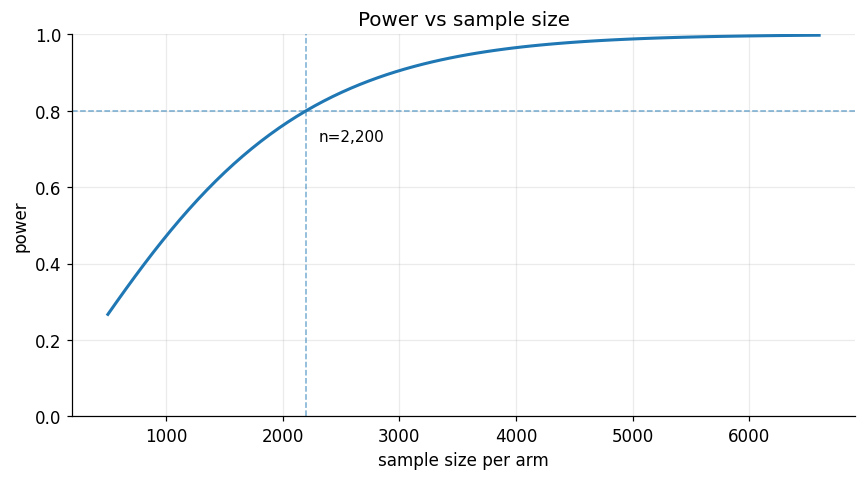

In [5]:
n_grid = np.linspace(500, analytical.n_per_arm * 3, 80, dtype=int)
powers = power_curve(baseline=BASELINE, mde_pp=MDE_PP, n_grid=n_grid, alpha=ALPHA)

_ = power_curve_plot(
    n_grid=n_grid,
    power_values=powers,
    target_power=POWER,
    target_n=analytical.n_per_arm,
    save_to=FIG_DIR / '02_power_curve.png',
)

## What lift can we detect for a given N?

In [6]:
n_table = np.array([1_000, 5_000, 10_000, 25_000, 50_000, 100_000])
mdes = mde_curve(baseline=BASELINE, n_grid=n_table, alpha=ALPHA, power=POWER)

tbl = pd.DataFrame({
    'n_per_arm': n_table,
    'detectable_lift_pp': np.round(mdes, 3),
    'detectable_lift_relative_%': np.round(mdes / (BASELINE * 100) * 100, 1),
})
tbl

,n_per_arm,detectable_lift_pp,detectable_lift_relative_%
0,1000,3.077,61.5
1,5000,1.291,25.8
2,10000,0.899,18.0
3,25000,0.560,11.2
4,50000,0.393,7.9
5,100000,0.277,5.5


## Operational read

With a baseline completion rate of about 5% and an MDE of 2pp at 80% power and alpha 0.05, this analysis needs the sample size shown above per arm.

If Noon's actual marketplace serves, hypothetically, 50,000 unique users per day to the cart-page treatment surface, the test would need to run for roughly `ceil(2 * analytical.n_per_arm / 50000)` days. Realistic experimentation cadence is shaped by this duration, not by what data scientists wish.

In [7]:
daily_traffic_per_arm = 25_000
days_required = int(np.ceil(analytical.n_per_arm / daily_traffic_per_arm))
print(f'assumed daily traffic per arm: {daily_traffic_per_arm:,}')
print(f'estimated duration:            {days_required} day(s)')

assumed daily traffic per arm: 25,000
estimated duration:            1 day(s)
